In [ ]:
import os
import sys

# Otteniamo il percorso assoluto della cartella corrente in cui Python sta eseguendo
current_dir = os.getcwd()

# Se il path finisce con 'notebooks', stiamo eseguendo in locale dentro la sottocartella.
# Dobbiamo salire di un livello per arrivare alla root del progetto (CLARITY)
if current_dir.endswith('notebooks'):
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    # Se NON finisce con 'notebooks', siamo già nella root (es. script di setup su Colab)
    project_root = current_dir

# Aggiungiamo la root al sys.path solo se non c'è già
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import config
from src.dataset import ClarityEvasionDataset

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import load_dataset
import pandas as pd
import numpy as np

# Librerie per l'analisi (Scikit-Learn e Seaborn per le matrici)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f"[*] MODALITÀ DEBUG ATTIVA? : {config.DEBUG_MODE}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] DEVICE DISPONIBILE     : {device.type.upper()}")

e:\Riky\Documents\Poli\CLARITY\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[*] MODALITÀ DEBUG ATTIVA? : True
[*] DEVICE DISPONIBILE     : CUDA


In [2]:
import pickle

val_path = os.path.join(config.DATA_DIR, "val_dataset.pkl")
print(f"\n[*] Caricamento Validation Set da: {val_path}")
with open(val_path, 'rb') as f:
    val_dataset = pickle.load(f)

print(f"Esempi nel Validation set da valutare: {len(val_dataset)}")

# Caricamento Modello e Tokenizer
model_path = os.path.join(config.MODELS_DIR, "best_evasion_encoder")
print(f"\n[*] Caricamento Modello e Tokenizer da: {model_path}")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)


[*] Caricamento Validation Set da: e:\Riky\Documents\Poli\CLARITY\notebooks\data\val_dataset.pkl
Esempi nel Validation set da valutare: 10

[*] Caricamento Modello e Tokenizer da: e:\Riky\Documents\Poli\CLARITY\notebooks\saved_models\best_evasion_encoder


In [3]:
trainer = Trainer(model=model)

print("\n[*] Calcolo delle predizioni sul Validation Set...")
predictions_output = trainer.predict(val_dataset)

# Ora label_ids non sarà None, perché il Validation Set ha le etichette vere!
logits = predictions_output.predictions
true_evasion_ids = predictions_output.label_ids
pred_evasion_ids = np.argmax(logits, axis=-1)

# Convertiamo gli ID (0-8) nelle stringhe leggibili
true_evasion_labels = [config.ID2EVASION[id] for id in true_evasion_ids]
pred_evasion_labels = [config.ID2EVASION[id] for id in pred_evasion_ids]

print("[✓] Inferenza Completata.")


[*] Calcolo delle predizioni sul Validation Set...


100%|██████████| 2/2 [00:00<00:00, 165.33it/s]

[✓] Inferenza Completata.



 RISULTATI TASK 2: 9 TECNICHE DI EVASIONE

Classification Report (Task 2):

                     precision    recall  f1-score   support

           Explicit       0.00      0.00      0.00       4.0
           Implicit       0.00      0.00      0.00       1.0
            Dodging       0.00      0.00      0.00       1.0
            General       0.00      0.00      0.00       3.0
         Deflection       0.00      0.00      0.00       0.0
Partial/half-answer       0.00      0.00      0.00       0.0
Declining to answer       0.00      0.00      0.00       0.0
   Claims ignorance       0.00      0.00      0.00       1.0
      Clarification       0.00      0.00      0.00       0.0

           accuracy                           0.00      10.0
          macro avg       0.00      0.00      0.00      10.0
       weighted avg       0.00      0.00      0.00      10.0


--> MACRO F1 UFFICIALE (TASK 2): 0.0000



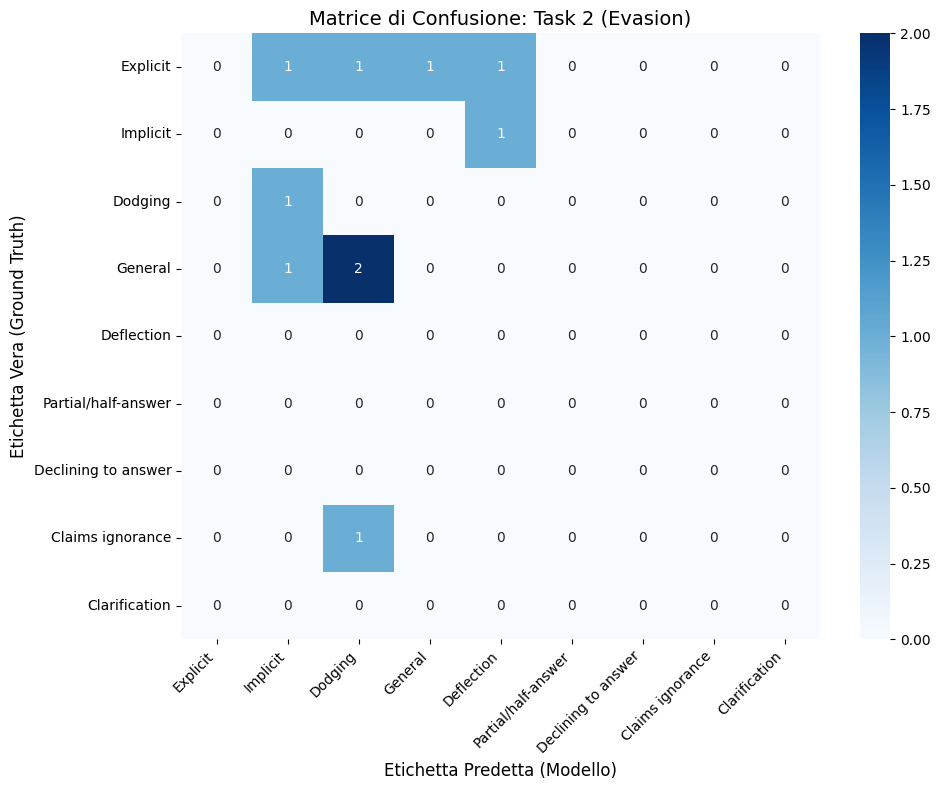

[*] Matrice salvata in: e:\Riky\Documents\Poli\CLARITY\notebooks\confusion_matrix_task2.png


In [4]:
print("\n" + "="*50)
print(" RISULTATI TASK 2: 9 TECNICHE DI EVASIONE")
print("="*50)

# Scikit-Learn genererà un report fantastico con Precision, Recall e F1 per ogni singola classe
report_task2 = classification_report(
    true_evasion_labels, 
    pred_evasion_labels, 
    labels=config.EVASION_LABELS, # Forziamo l'ordine delle classi come nel config
    zero_division=0
)
print("\nClassification Report (Task 2):\n")
print(report_task2)

macro_f1_task2 = f1_score(true_evasion_labels, pred_evasion_labels, average='macro', zero_division=0)
print(f"\n--> MACRO F1 UFFICIALE (TASK 2): {macro_f1_task2:.4f}\n")

# --- PLOT MATRICE DI CONFUSIONE TASK 2 ---
cm2 = confusion_matrix(true_evasion_labels, pred_evasion_labels, labels=config.EVASION_LABELS)

plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=config.EVASION_LABELS, yticklabels=config.EVASION_LABELS)
plt.title("Matrice di Confusione: Task 2 (Evasion)", fontsize=14)
plt.ylabel('Etichetta Vera (Ground Truth)', fontsize=12)
plt.xlabel('Etichetta Predetta (Modello)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Salviamo l'immagine se vogliamo metterla nella presentazione
plot_path = os.path.join(config.ROOT_DIR, "confusion_matrix_task2.png")
plt.tight_layout()
plt.savefig(plot_path)
plt.show()
print(f"[*] Matrice salvata in: {plot_path}")


 RISULTATI TASK 1: 3 MACRO-CLASSI DI CHIAREZZA

Classification Report (Task 1 dedotto dal Task 2):

                 precision    recall  f1-score   support

    Clear Reply       0.00      0.00      0.00         4
     Ambivalent       0.50      1.00      0.67         5
Clear Non-Reply       0.00      0.00      0.00         1

       accuracy                           0.50        10
      macro avg       0.17      0.33      0.22        10
   weighted avg       0.25      0.50      0.33        10


--> MACRO F1 UFFICIALE (TASK 1): 0.2222



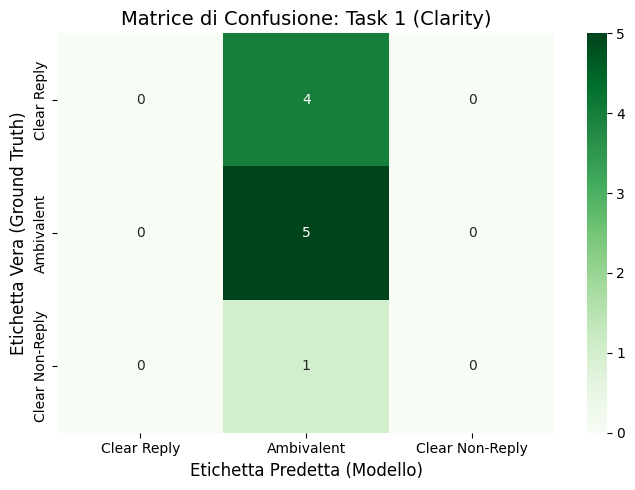

[*] Matrice salvata in: e:\Riky\Documents\Poli\CLARITY\notebooks\confusion_matrix_task1.png


In [5]:
print("\n" + "="*50)
print(" RISULTATI TASK 1: 3 MACRO-CLASSI DI CHIAREZZA")
print("="*50)

# 1. Mappiamo le etichetteVERE del test set usando il dizionario gerarchico
# Se nel dataset originale il campo clarity_label non fosse perfettamente allineato, 
# la gara solitamente valuta comunque la mappatura logica (il paper stesso lo fa).
true_clarity_labels = [config.EVASION_TO_CLARITY_MAP[label] for label in true_evasion_labels]

# 2. Mappiamo le etichette PREDETTE dal nostro modello
pred_clarity_labels = [config.EVASION_TO_CLARITY_MAP[label] for label in pred_evasion_labels]

# Generiamo il report
report_task1 = classification_report(
    true_clarity_labels, 
    pred_clarity_labels, 
    labels=config.CLARITY_LABELS, # ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
    zero_division=0
)

print("\nClassification Report (Task 1 dedotto dal Task 2):\n")
print(report_task1)

macro_f1_task1 = f1_score(true_clarity_labels, pred_clarity_labels, average='macro', zero_division=0)
print(f"\n--> MACRO F1 UFFICIALE (TASK 1): {macro_f1_task1:.4f}\n")

# --- PLOT MATRICE DI CONFUSIONE TASK 1 ---
cm1 = confusion_matrix(true_clarity_labels, pred_clarity_labels, labels=config.CLARITY_LABELS)

plt.figure(figsize=(7, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens',
            xticklabels=config.CLARITY_LABELS, yticklabels=config.CLARITY_LABELS)
plt.title("Matrice di Confusione: Task 1 (Clarity)", fontsize=14)
plt.ylabel('Etichetta Vera (Ground Truth)', fontsize=12)
plt.xlabel('Etichetta Predetta (Modello)', fontsize=12)

plot_path_t1 = os.path.join(config.ROOT_DIR, "confusion_matrix_task1.png")
plt.tight_layout()
plt.savefig(plot_path_t1)
plt.show()
print(f"[*] Matrice salvata in: {plot_path_t1}")

In [6]:
print("\n" + "="*50)
print(" GENERAZIONE FILE DI SUBMISSION PER SEMEVAL")
print("="*50)

print("\n[*] Scaricamento del Test Set Ufficiale...")
dataset = load_dataset(config.DATASET_URL)
if 'test' in dataset:
    df_test = dataset['test'].to_pandas()
    
    # Rimuoviamo colonne inutili per la creazione del dataset HF
    if "__index_level_0__" in df_test.columns:
        df_test = df_test.drop(columns=["__index_level_0__"])
        
    print(f"Esempi nel Test set cieco: {len(df_test)}")
    
    # Convertiamo in HF Dataset
    from datasets import Dataset as HFDataset
    hf_test = HFDataset.from_pandas(df_test)
    
    # Usiamo il nostro custom dataset
    test_dataset = ClarityEvasionDataset(
        hf_dataset=hf_test,
        tokenizer=tokenizer,
        max_len=config.MAX_LEN,
        evasion2id=config.EVASION2ID
    )
    
    print("\n[*] Predizione in corso sul Test Set...")
    test_preds_output = trainer.predict(test_dataset)
    test_logits = test_preds_output.predictions
    test_pred_ids = np.argmax(test_logits, axis=-1)
    
    # Decodifichiamo i risultati per i due task
    test_evasion_labels = [config.ID2EVASION[id] for id in test_pred_ids]
    test_clarity_labels = [config.EVASION_TO_CLARITY_MAP[label] for label in test_evasion_labels]
    
    # Aggiungiamo le predizioni al dataframe
    df_test['predicted_evasion_label'] = test_evasion_labels
    df_test['predicted_clarity_label'] = test_clarity_labels
    
    # Salviamo in CSV
    submission_path = os.path.join(config.ROOT_DIR, "submission.csv")
    
    # Salviamo solo le colonne richieste da SemEval (solitamente ID, question, answer, le due predizioni)
    cols_to_save = ['interview_question', 'question', 'interview_answer', 'predicted_clarity_label', 'predicted_evasion_label']
    
    # Assicuriamoci che le colonne esistano
    cols_to_save = [c for c in cols_to_save if c in df_test.columns]
    
    df_test[cols_to_save].to_csv(submission_path, index=False)
    print(f"\n[✓] File di submission salvato con successo in: {submission_path}")
    
else:
    print("\n[!] Lo split 'test' non è presente nel dataset HuggingFace attualmente.")


 GENERAZIONE FILE DI SUBMISSION PER SEMEVAL

[*] Scaricamento del Test Set Ufficiale...
Esempi nel Test set cieco: 308

[*] Predizione in corso sul Test Set...


100%|██████████| 39/39 [00:00<00:00, 58.68it/s]



[✓] File di submission salvato con successo in: e:\Riky\Documents\Poli\CLARITY\notebooks\submission.csv
